In [27]:
#You will be using the dataset us_retail_sales.csv for this assignment. 
#This data gives the total monthly retail sales in the US from
#January 1992 until June 2021. With this dataset, complete the following steps:

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import autocorrelation_plot

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [14]:
#read data files

url_1 = "us_retail_sales.csv"
df = pd.read_csv(url_1, encoding="latin1")  # or utf-8 if latin1 fails

print(df.shape)        # (rows, columns)
print(df.info()) #no missing values indicated


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

(30, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    30 non-null     int64  
 1   JAN     30 non-null     int64  
 2   FEB     30 non-null     int64  
 3   MAR     30 non-null     int64  
 4   APR     30 non-null     int64  
 5   MAY     30 non-null     int64  
 6   JUN     30 non-null     int64  
 7   JUL     29 non-null     float64
 8   AUG     29 non-null     float64
 9   SEP     29 non-null     float64
 10  OCT     29 non-null     float64
 11  NOV     29 non-null     float64
 12  DEC     29 non-null     float64
dtypes: float64(6), int64(7)
memory usage: 3.2 KB
None


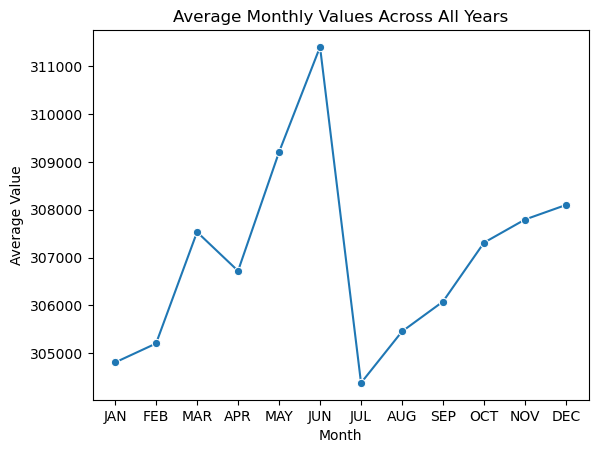

In [15]:
#Plot the data with proper labeling and make some observations on the graph.

month_cols = ["JAN","FEB","MAR","APR","MAY","JUN",
              "JUL","AUG","SEP","OCT","NOV","DEC"]

# Compute means
means = df[month_cols].mean()

# Convert to a DataFrame for Seaborn
plot_df = pd.DataFrame({
    'Month': means.index,
    'Average': means.values
})

# Plot
sns.lineplot(x='Month', y='Average', data=plot_df, marker='o')
plt.title("Average Monthly Values Across All Years")
plt.xlabel("Month")
plt.ylabel("Average Value")
plt.show()

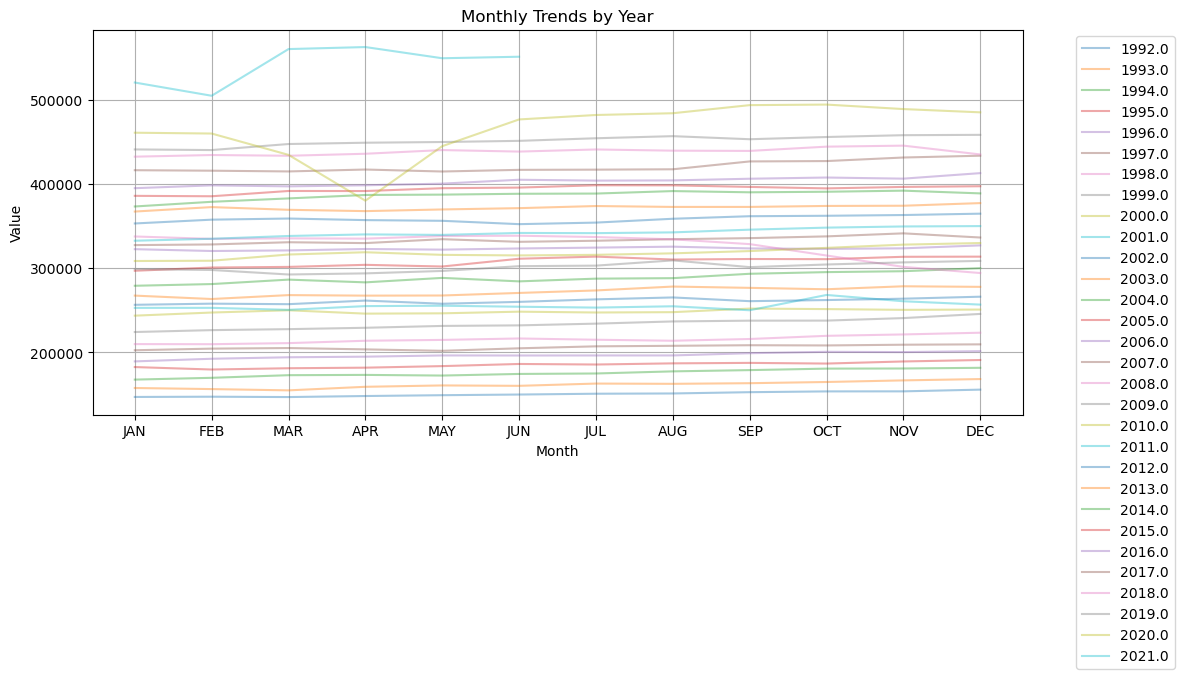

In [16]:
plt.figure(figsize=(12,5))

for _, row in df.iterrows():
    plt.plot(month_cols, row[month_cols], alpha=0.4, label=row["YEAR"])

plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Monthly Trends by Year")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", ncol=1)
plt.show()

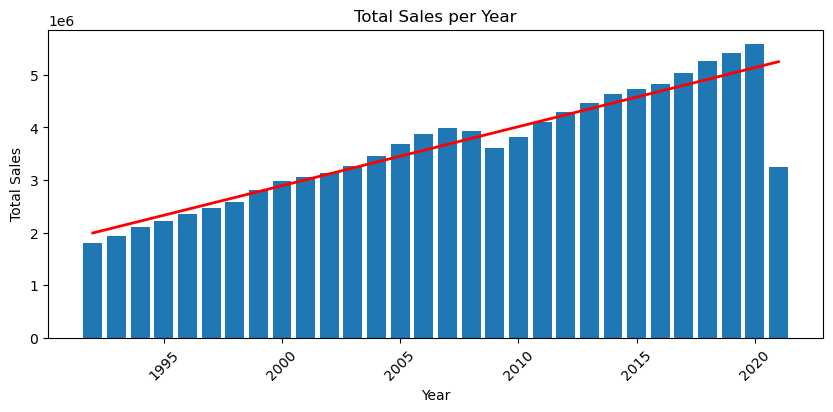

In [17]:
# month columns to sum
month_cols = ["JAN","FEB","MAR","APR","MAY","JUN",
              "JUL","AUG","SEP","OCT","NOV","DEC"]

# create a new column with the yearly total
df["YEAR_TOTAL"] = df[month_cols].sum(axis=1)

# plot
plt.figure(figsize=(10,4))
plt.bar(df["YEAR"], df["YEAR_TOTAL"])

# trend line
z = np.polyfit(df["YEAR"], df["YEAR_TOTAL"], 1)   # linear fit
p = np.poly1d(z)
plt.plot(df["YEAR"], p(df["YEAR"]), color='red', linewidth=2, label='Trend Line')

# labels and title
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Total Sales per Year")
plt.xticks(rotation=45)      # rotate for readability
plt.show()

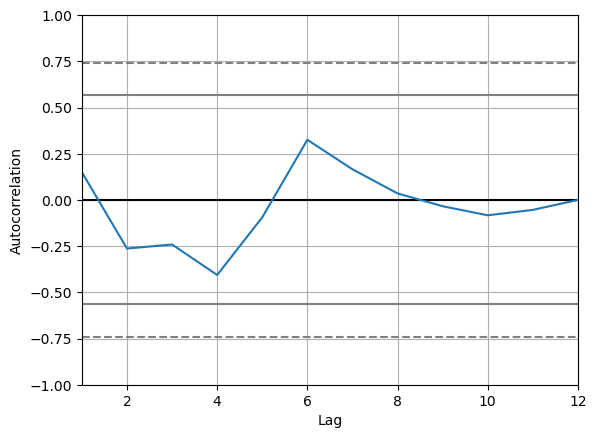

In [18]:
autocorrelation_plot(means)
plt.show()

#Autocorrelation refers to the degree of correlation of the same 
#variables between two successive time intervals. 
#It measures how the lagged version of the value of a variable is 
#related to the original version of it in a time series.

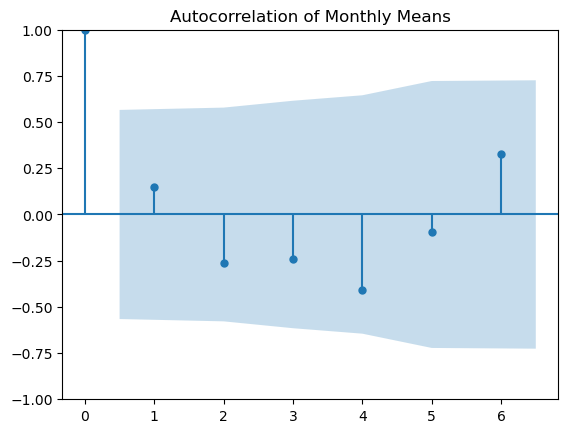

In [19]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(means)
plt.title("Autocorrelation of Monthly Means")
plt.show()

In [28]:
#Split this data into a training and test set. 
#Use the last year of data (July 2020 – June 2021) 
#of data as your test set and the rest as your training set.

#To use SARIMA, the data will need to be reshaped it into a long (time series) format
#where each row is one month with a proper date.

# Assuming your DataFrame is called df
month_order = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG",\
               "SEP","OCT","NOV","DEC"]

# Melt wide → long
df_long = df.melt(id_vars=['YEAR'], value_vars=month_order, 
                  var_name='MONTH', value_name='mean')

# Combine YEAR and MONTH into a datetime
df_long['DATE'] = pd.to_datetime(df_long['YEAR'].astype(str) + '-' +\
                                 df_long['MONTH'], format='%Y-%b')

# Sort chronologically and set DATE as index
df_long = df_long.sort_values('DATE').set_index('DATE')

#print(df_long.head(15))

#set frequency to ensure there are no gaps
df_long = df_long.asfreq('MS')  # monthly start

train = df_long.loc[:'2020-06-01']
test  = df_long.loc['2020-07-01':'2021-06-01']

print(train.tail(3))
print(test.head(3))



            YEAR MONTH      mean
DATE                            
2020-04-01  2020   APR  379892.0
2020-05-01  2020   MAY  444631.0
2020-06-01  2020   JUN  476343.0
            YEAR MONTH      mean
DATE                            
2020-07-01  2020   JUL  481627.0
2020-08-01  2020   AUG  483716.0
2020-09-01  2020   SEP  493327.0


In [21]:
#Use the training set to build a predictive model for the monthly retail sales.

model = SARIMAX(train['mean'], order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()


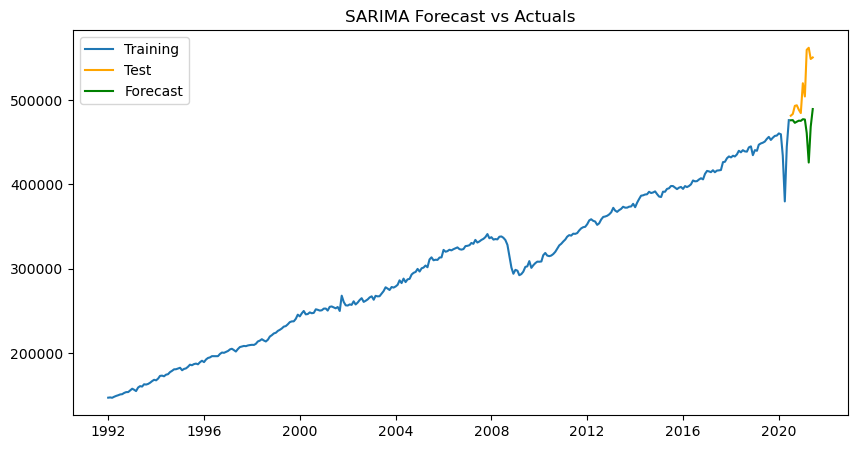

In [22]:
#Use the model to predict the monthly retail sales on the last year of data.

# Forecast for test period
forecast = results.predict(start=test.index[0], end=test.index[-1])

# Plot
plt.figure(figsize=(10,5))
plt.plot(train.index, train['mean'], label='Training')
plt.plot(test.index, test['mean'], label='Test', color='orange')
plt.plot(forecast.index, forecast, label='Forecast', color='green')
plt.legend()
plt.title("SARIMA Forecast vs Actuals")
plt.show()

In [23]:
#Report the RMSE of the model predictions on the test set

rmse = np.sqrt(mean_squared_error(test['mean'], forecast))
print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 59307.28


In [24]:
df_long['mean'].describe()

count       354.000000
mean     307006.573446
std       94335.828235
min      146805.000000
25%      231402.000000
50%      309534.500000
75%      378193.750000
max      562269.000000
Name: mean, dtype: float64

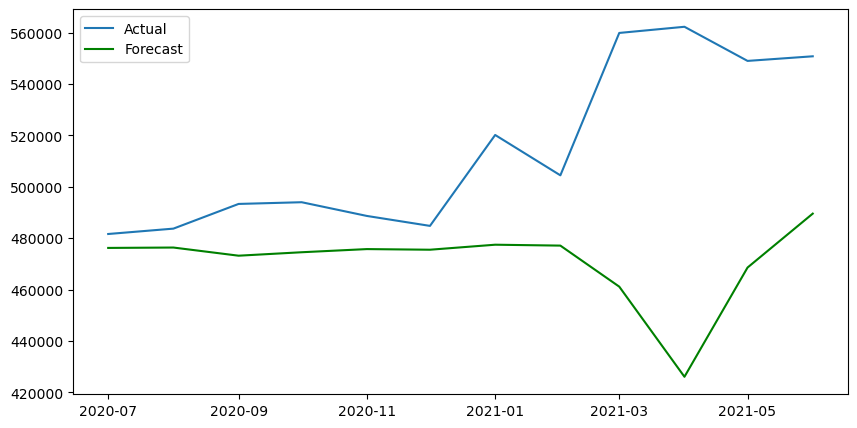

In [25]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test['mean'], label='Actual')
plt.plot(forecast.index, forecast, label='Forecast', color='green')
plt.legend()
plt.show()

In [29]:
def smape(actual, forecast):
    return 100/len(actual) * np.sum(np.abs(forecast - actual) \
                                    / ((np.abs(actual) + np.abs(forecast)) / 2))

# Example
actual = np.array([100, 200, 300, 400])
forecast = np.array([110, 190, 310, 380])

result = smape(actual, forecast)
print(f"SMAPE: {result:.2f}%")

SMAPE: 5.76%
